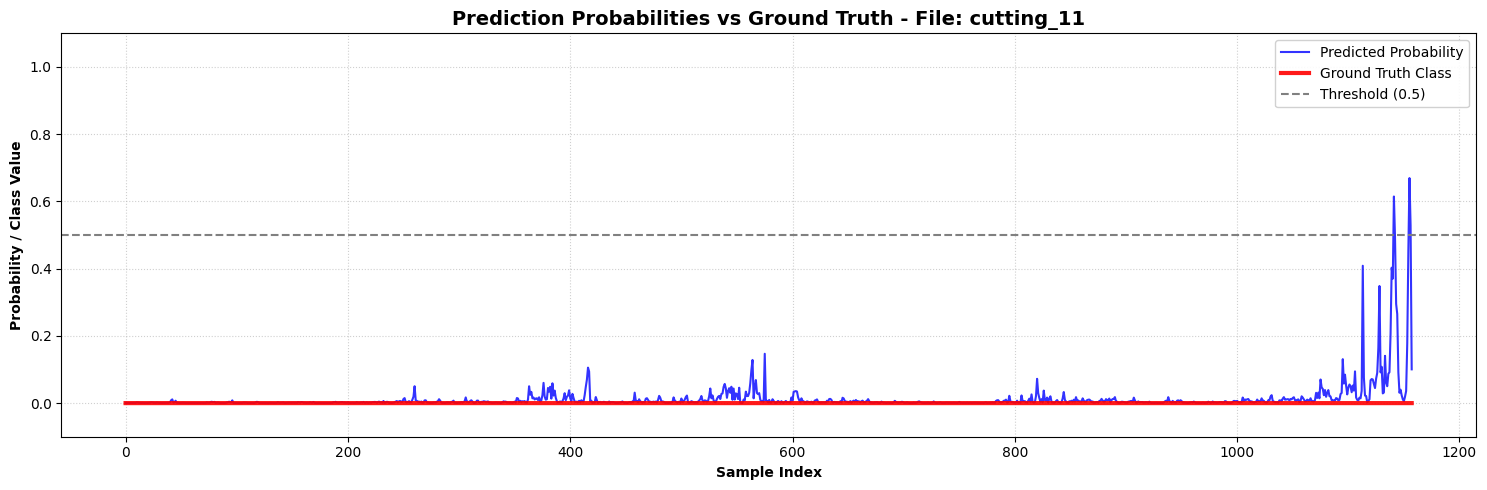

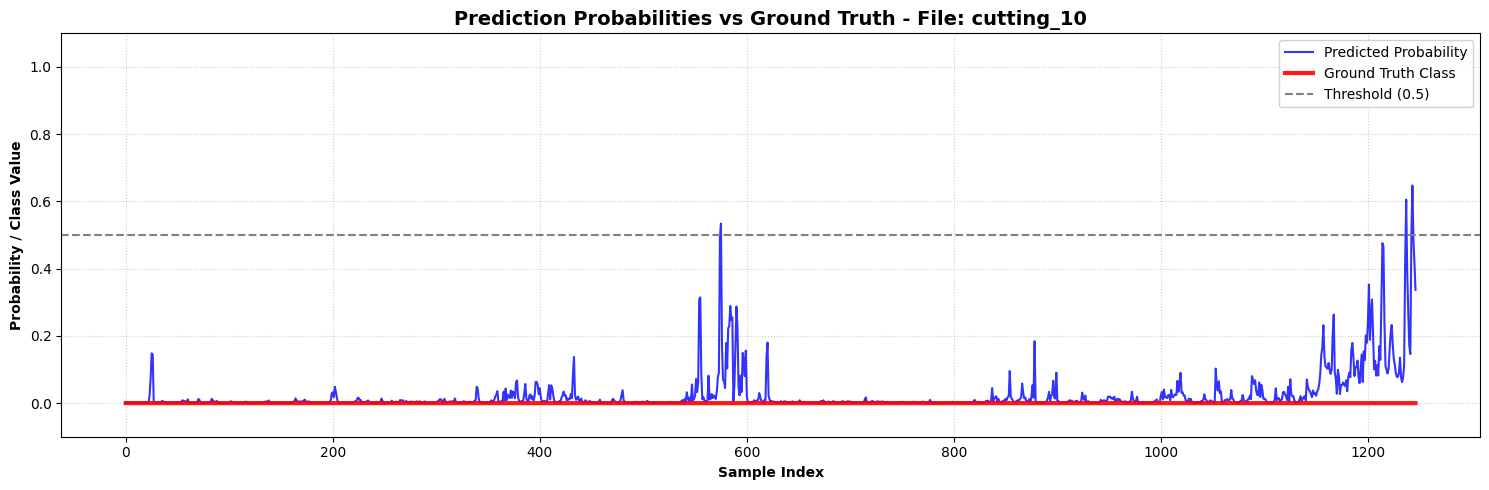

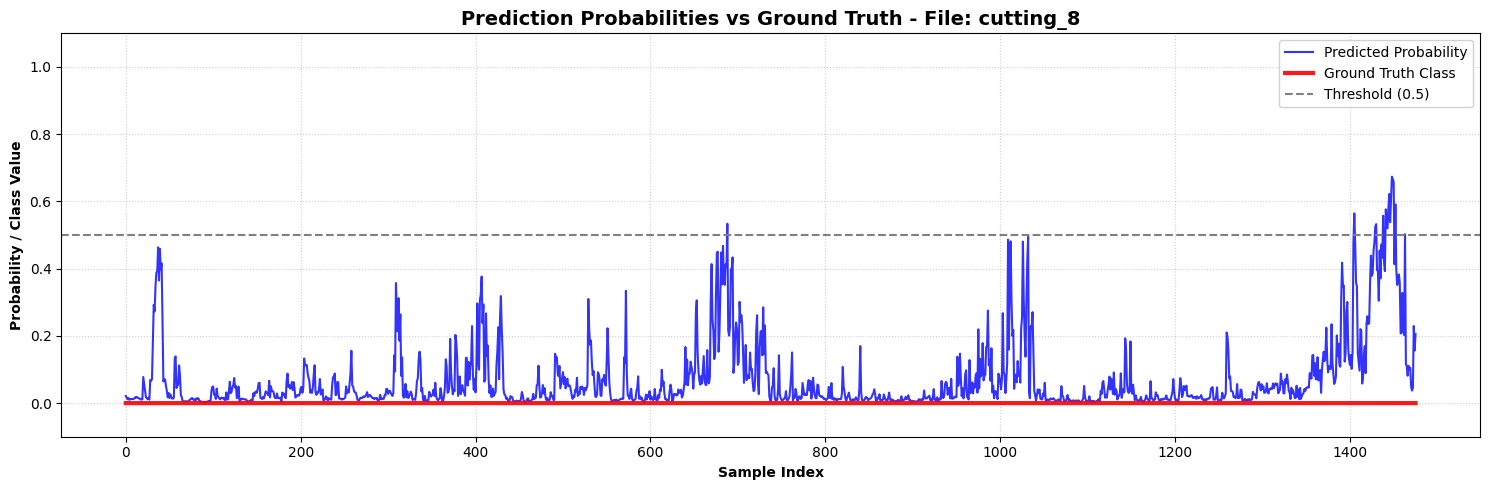

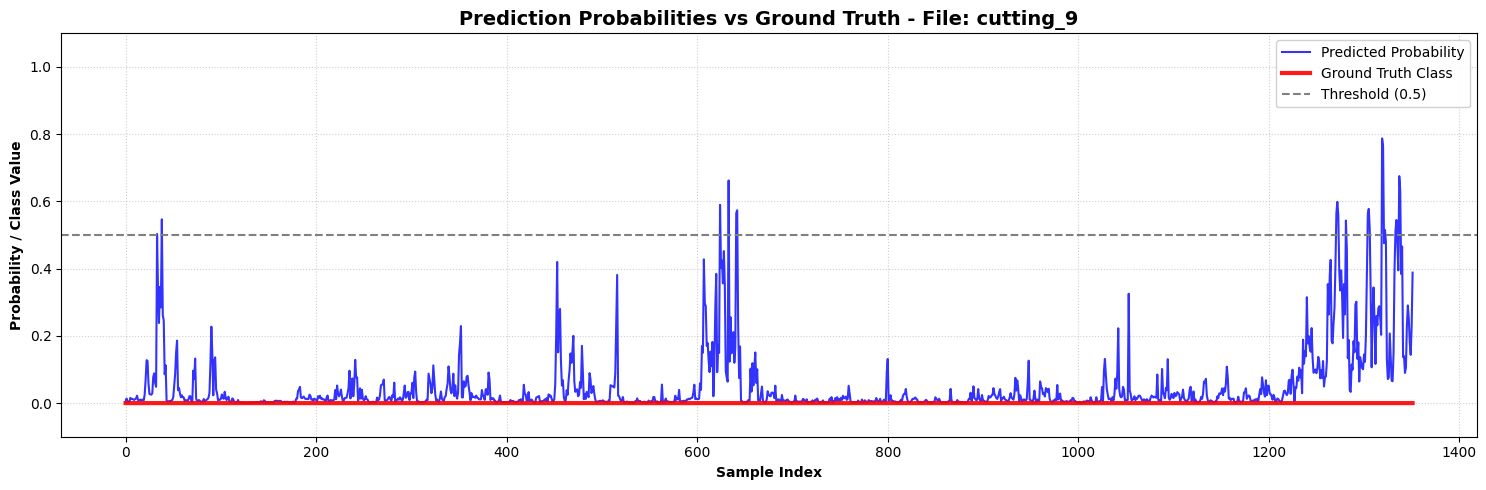

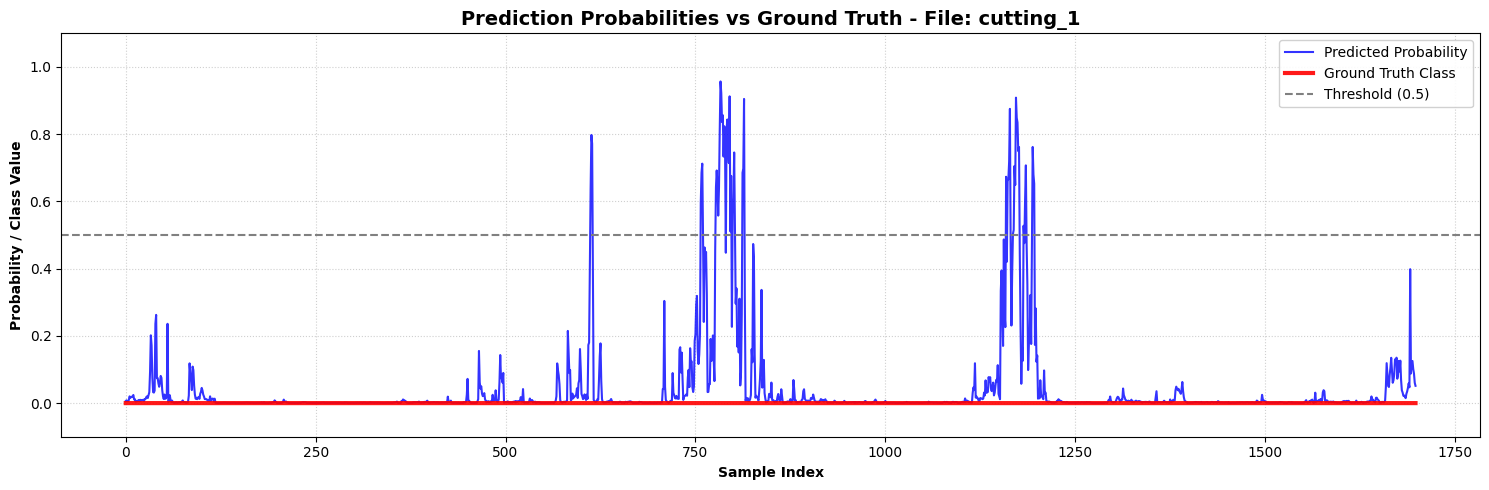

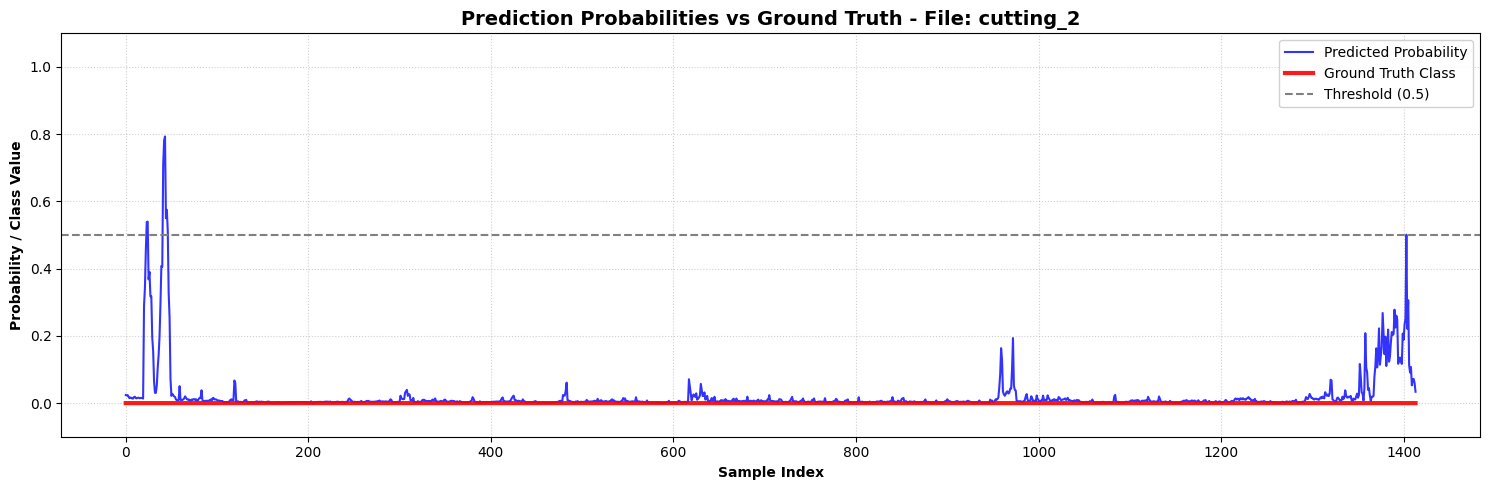

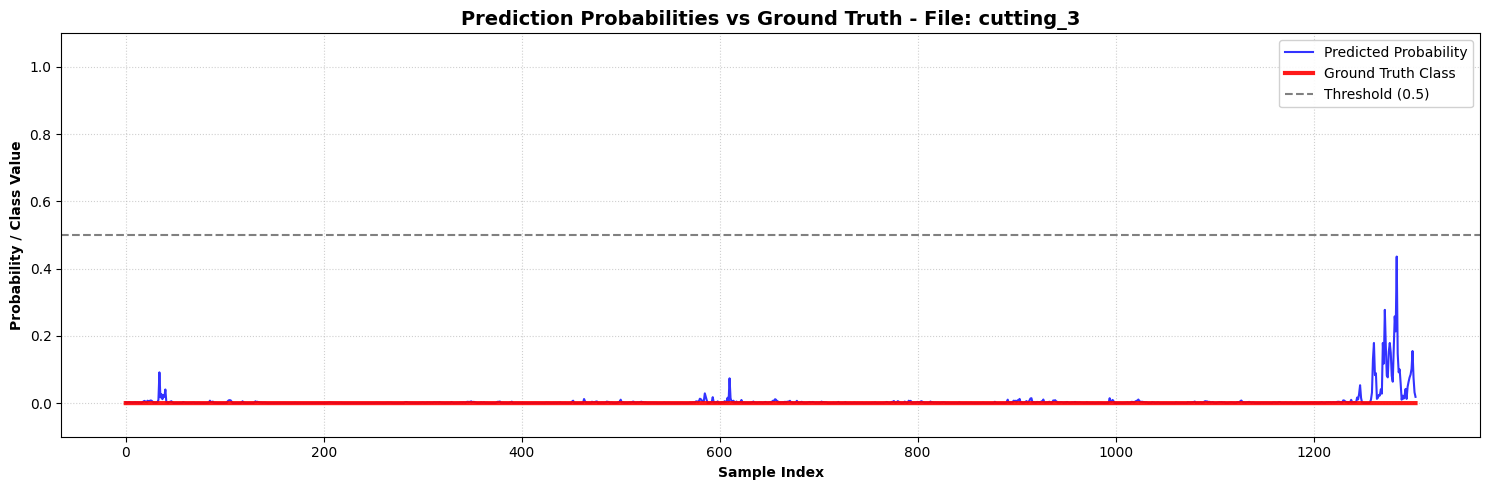

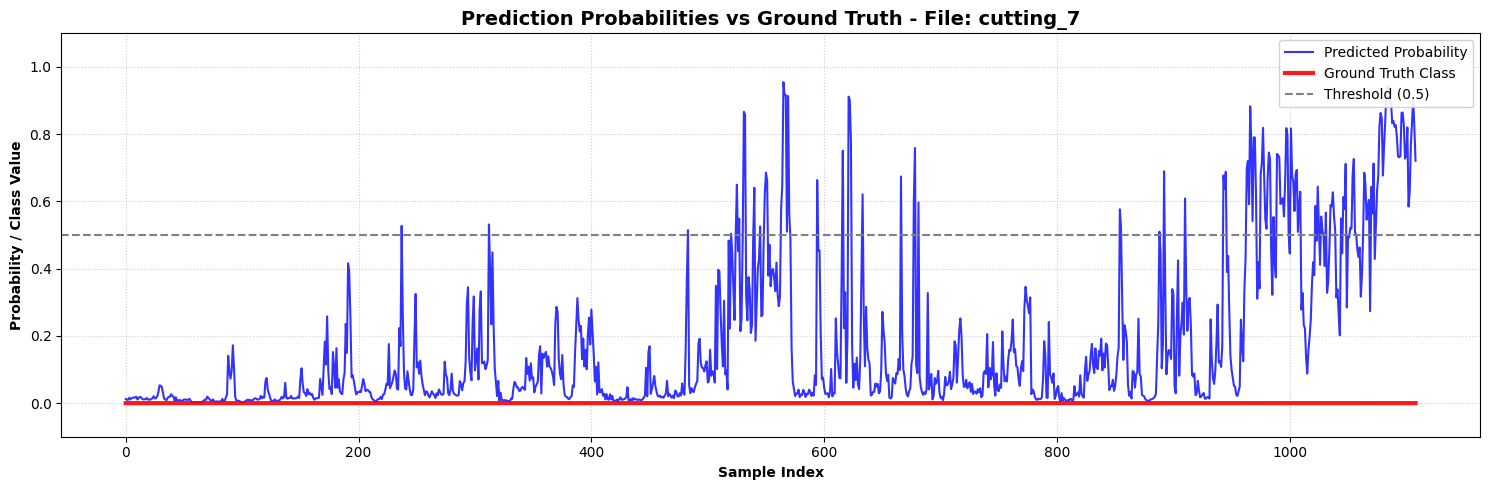

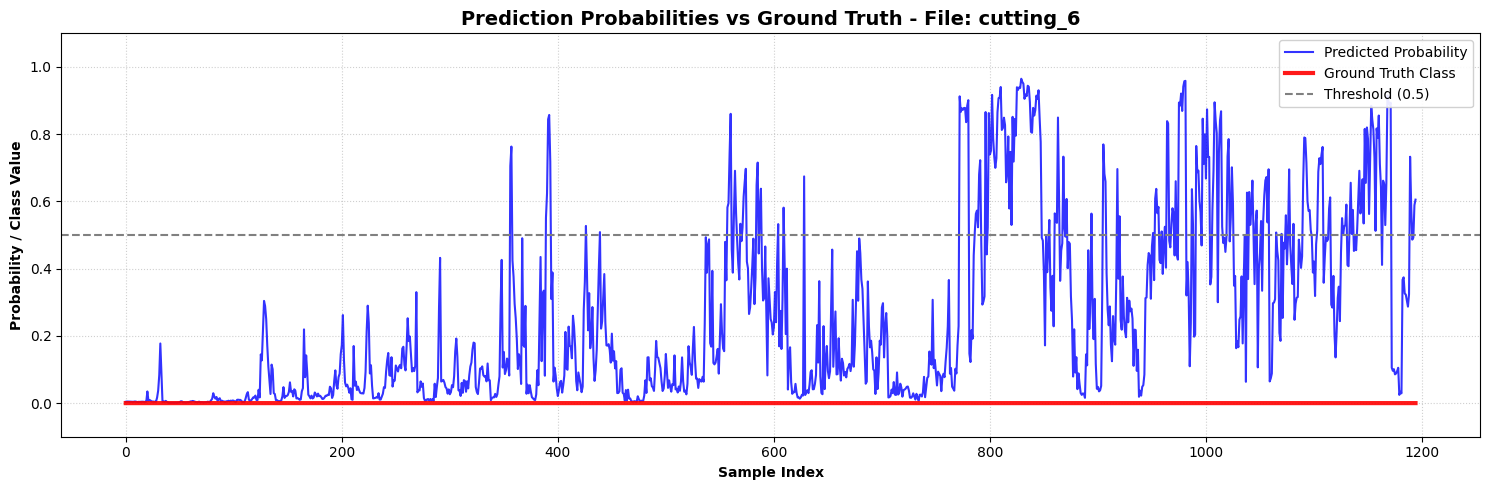

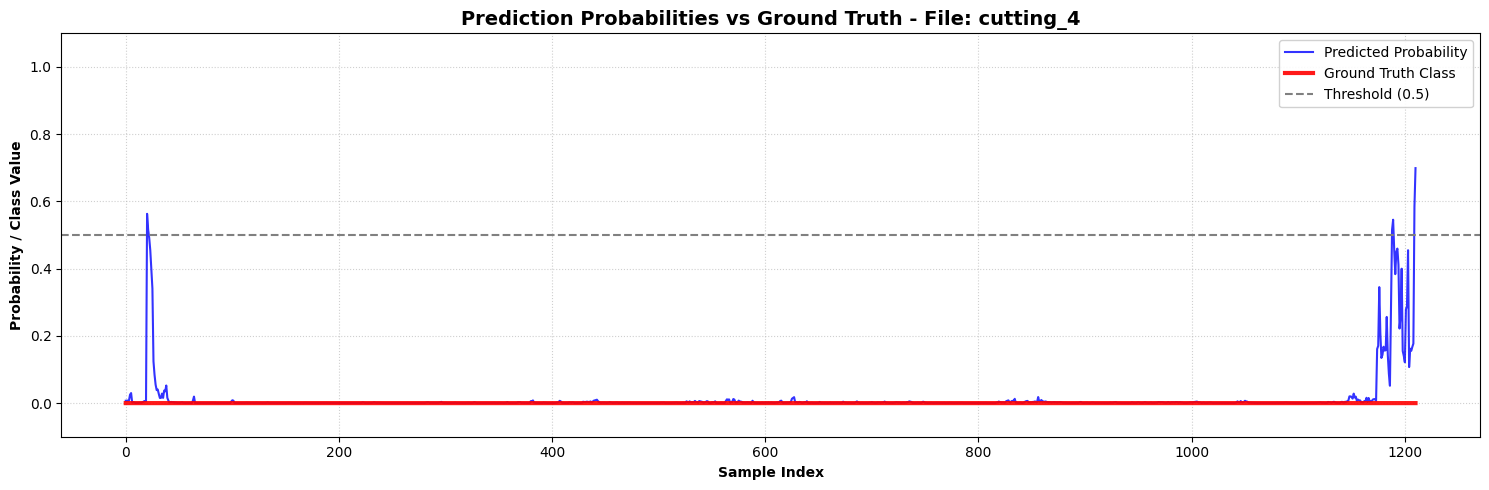

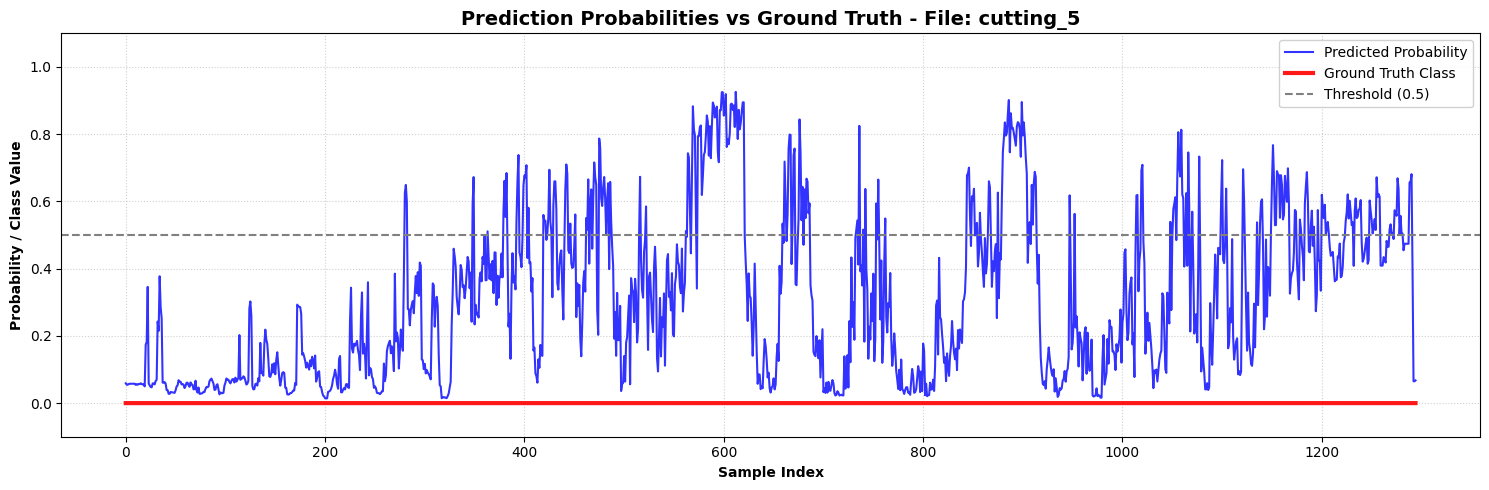

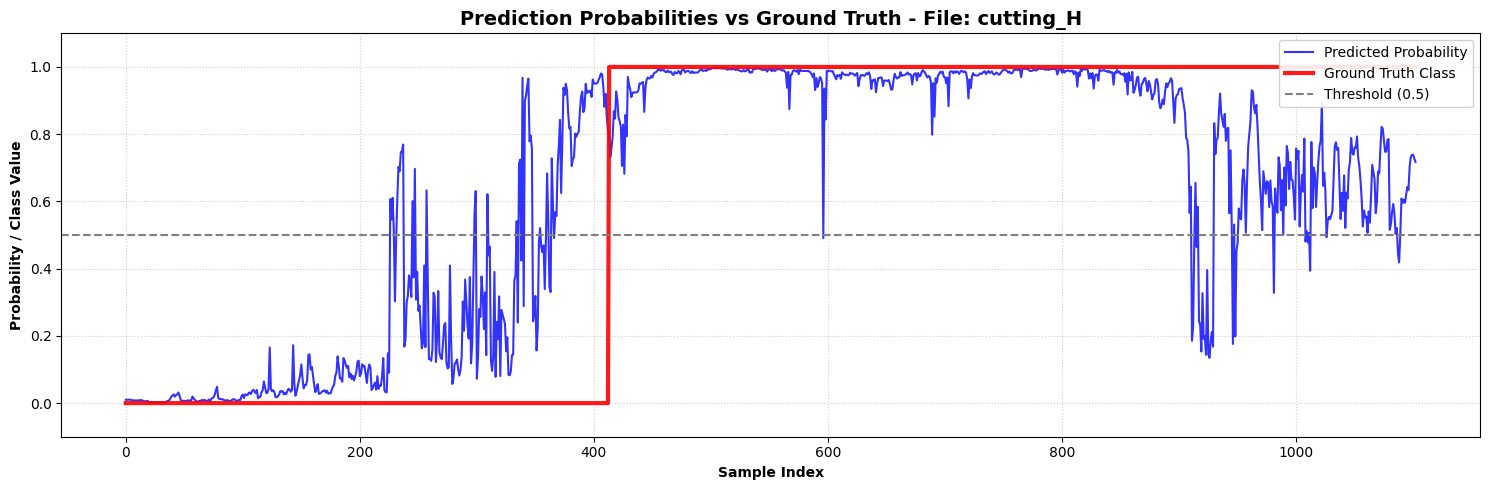

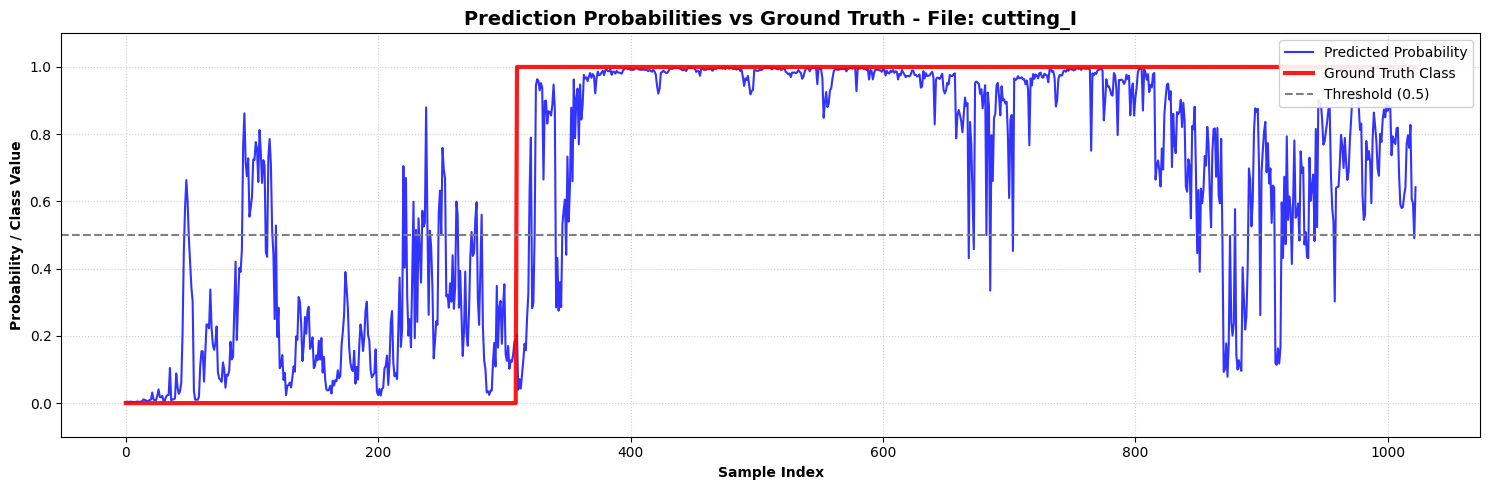

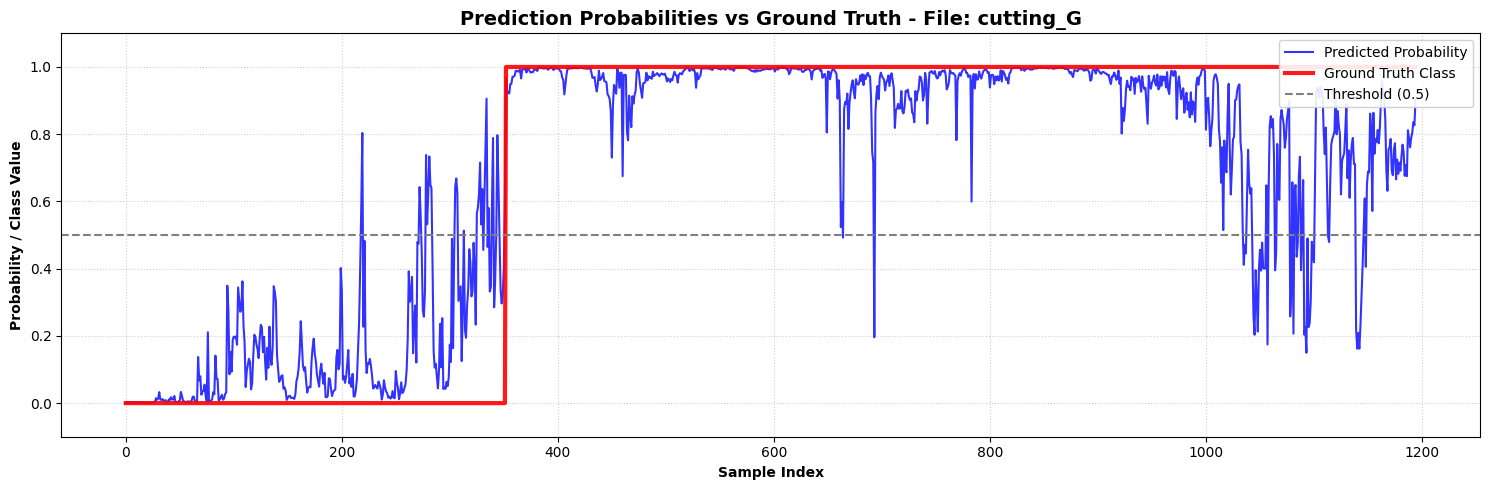

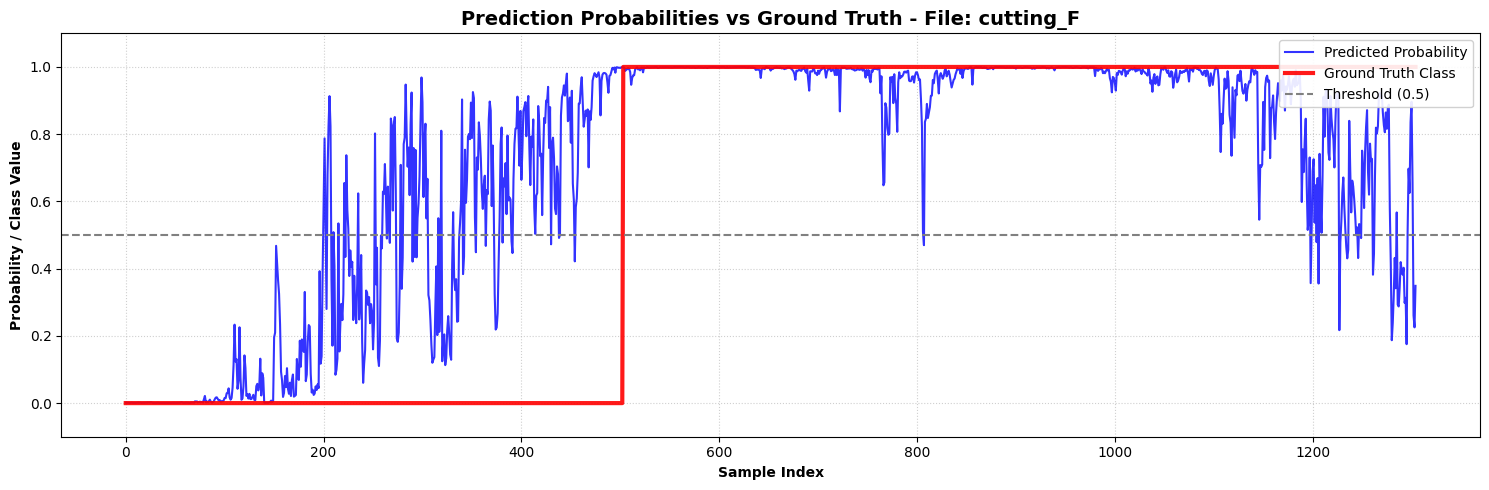

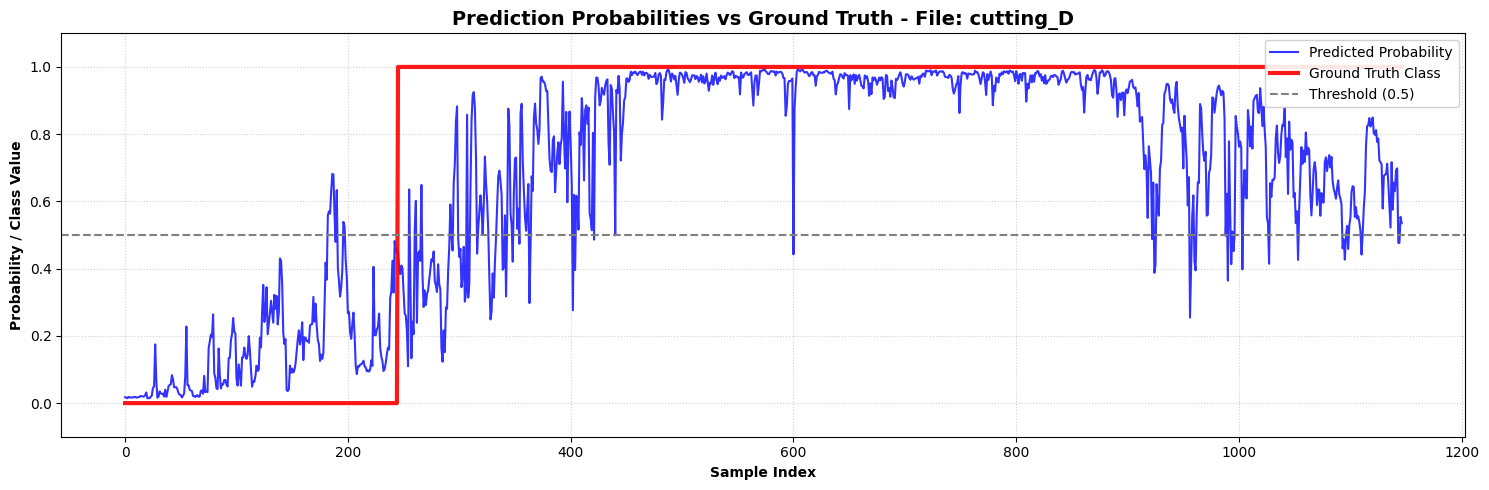

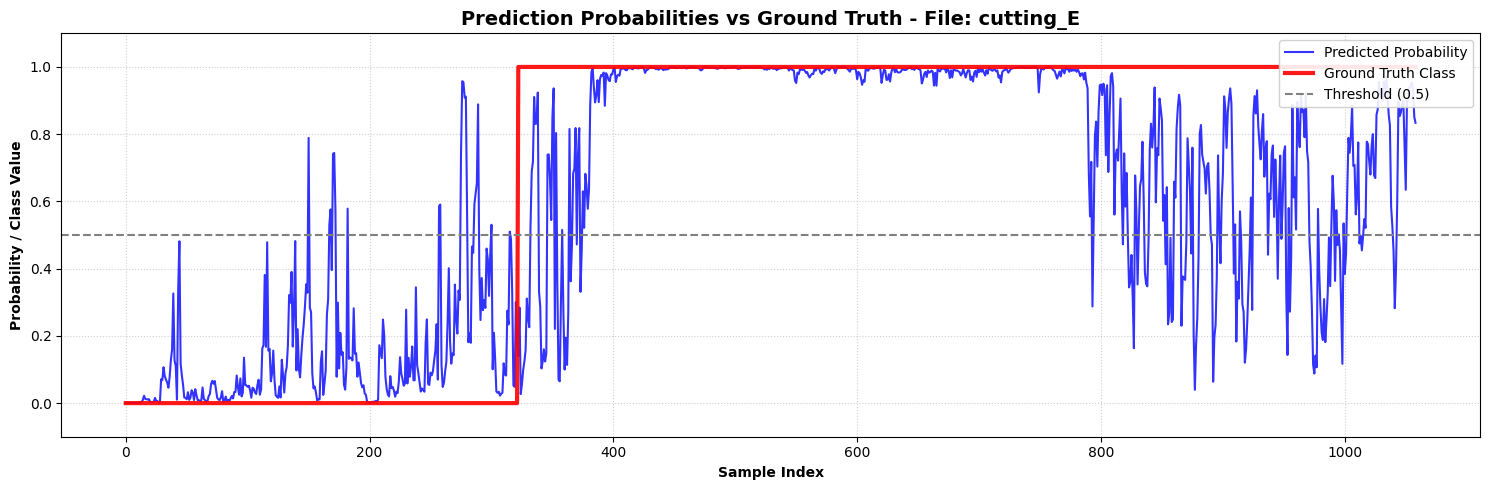

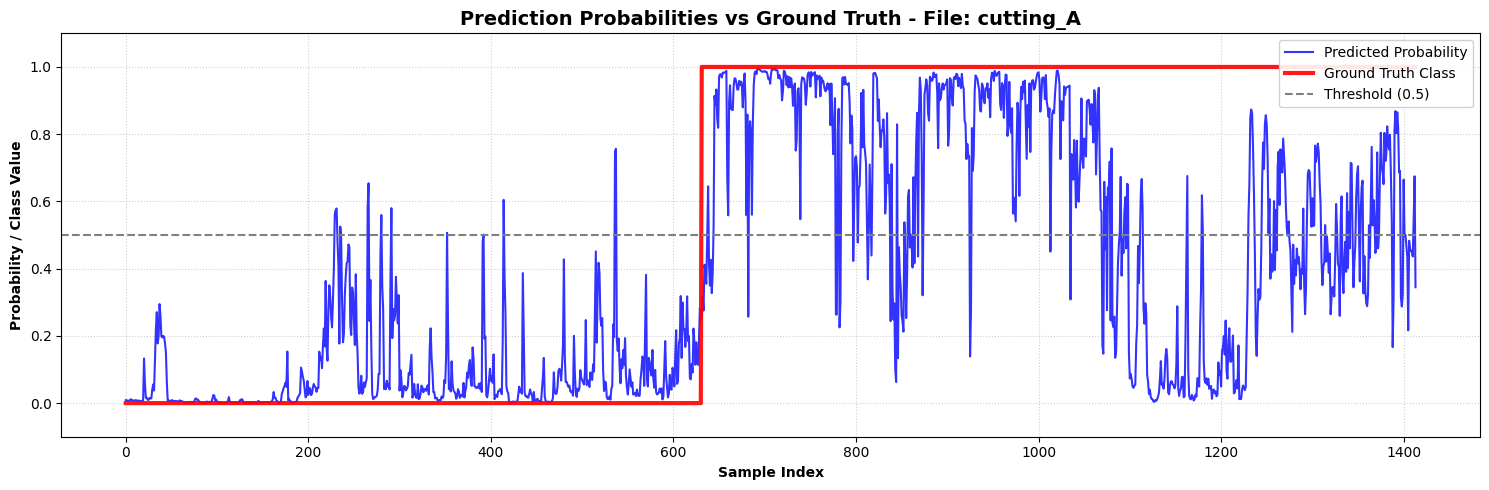

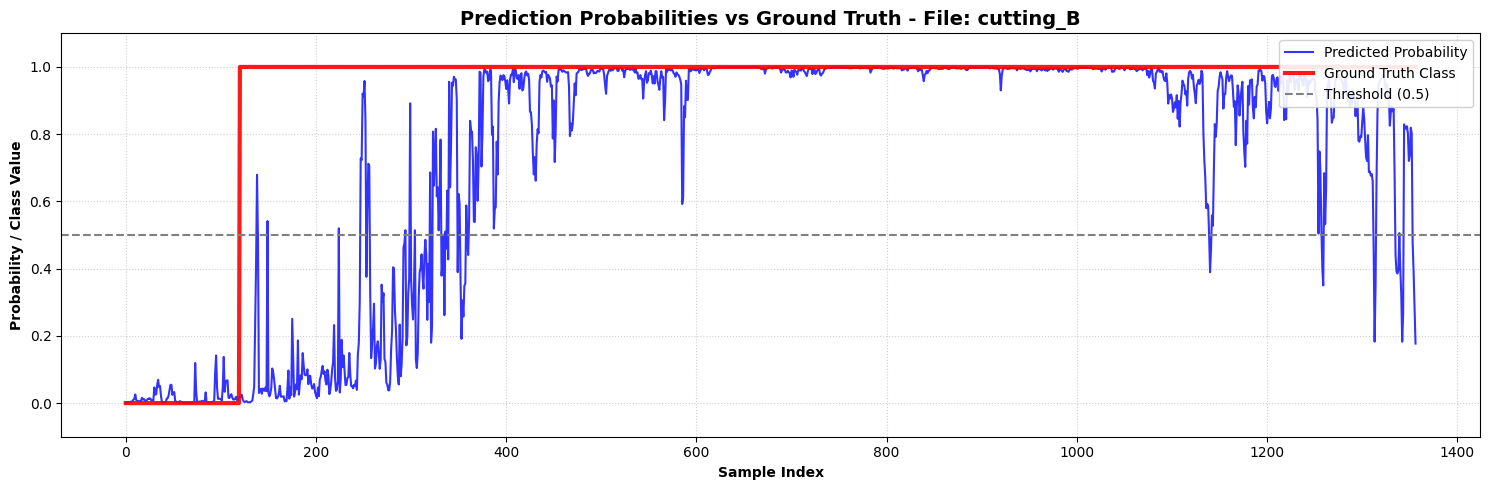

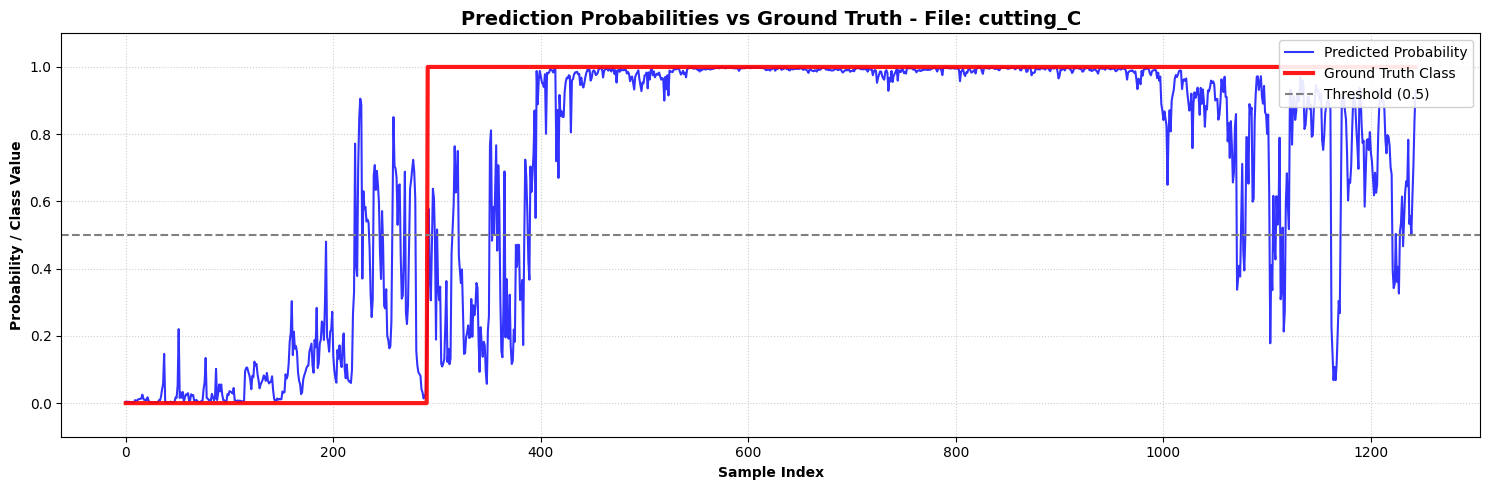

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define the file path and load the data
results_dir = "../02_Processed_Data/07_Model_Results"
csv_path = os.path.join(results_dir, "LOOCV_Predictions_Results.csv")

# Load the predictions dataframe
df_results = pd.read_csv(csv_path)

# 2. Get unique File IDs to create a separate plot for each file
unique_files = df_results['File_ID'].unique()

# 3. Loop through each file and generate the plot
for file_id in unique_files:
    # Extract data specifically for the current file
    file_data = df_results[df_results['File_ID'] == file_id].reset_index(drop=True)
    
    # Initialize the plot
    plt.figure(figsize=(15, 5))
    
    # Plot Probability (Blue line)
    plt.plot(file_data.index, file_data['Probability'], 
             color='blue', linewidth=1.5, alpha=0.8, label='Predicted Probability')
    
    # Plot True Class (Red, thick line)
    plt.plot(file_data.index, file_data['True_Class'], 
             color='red', linewidth=3.0, alpha=0.9, label='Ground Truth Class')
    
    # Add Threshold Line (Dashed, at 0.5)
    plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
    
    # Formatting and English Labels
    plt.title(f"Prediction Probabilities vs Ground Truth - File: {file_id}", fontweight='bold', fontsize=14)
    plt.xlabel("Sample Index", fontweight='bold')
    plt.ylabel("Probability / Class Value", fontweight='bold')
    
    # Set y-axis limits slightly wider than 0-1 so lines don't get cut off at the very top/bottom
    plt.ylim(-0.1, 1.1)
    
    # Add Legend and Grid
    plt.legend(loc='upper right', framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Display the plot
    plt.show()